In [1]:
import pandas as pd
import numpy as np
import MDAnalysis

import MDAnalysis.analysis.rms
from MDAnalysis.analysis import rms
import seaborn as sns
import matplotlib.pyplot as plt

import os
import tqdm

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
prefix_path='../../../LC3_MAIN_TRAJECTORIES/PROTEIN_ONLY_FITTED'

#PRE
pre_LC3B_S1=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM1_dt1000.pdb'%prefix_path)
pre_LC3B_S2=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM2_dt1000.pdb'%prefix_path)
pre_LC3B_S3=MDAnalysis.Universe('%s/preLC3B_OPLS/preLC3B_OPLS_SIM3_dt1000.pdb'%prefix_path)


#UNB
u_unbound_ER_S1 = MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM1_dt1000.pdb"%prefix_path)
u_unbound_ER_S2 =MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM2_dt1000.pdb"%prefix_path)
u_unbound_ER_S3=MDAnalysis.Universe("%s/LC3B_II_ER_protein/LC3B_II_ER_protein_SIM3_dt1000.pdb"%prefix_path)

#BND
u_bound_ER_S1 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM1_dt1000.pdb"%prefix_path)
u_bound_ER_S2 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM2_dt1000.pdb"%prefix_path)
u_bound_ER_S3 = MDAnalysis.Universe("%s/LC3B_P62_INCLUDED/LC3B_P62_INCLUDED_SIM3_dt1000.pdb"%prefix_path)





In [3]:
# sb contacts
r70_pairs=[(70,48),(70,49)]

def cont_check(Traj,pairs):
    distt_ls=[]
    contact_stat=[]
    contact_count=0
    total_frames=len(Traj.trajectory)

    for t in Traj.trajectory:
        #selecting all the heavy atoms 
        sel1=Traj.select_atoms('resid %d and not type H'%pairs[0])
        sel2=Traj.select_atoms('resid %d and not type H'%pairs[1])
        
        sel1.universe.trajectory[t.frame]
        sel2.universe.trajectory[t.frame]
        
        if len(sel1.residues)==0 or len(sel2.residues)==0:
            contact_occup=0
        else:
            dist_ls=[]
            for i in sel1.atoms:
                for j in sel2.atoms:

                    pos_1=np.array(i.position)  
                    pos_2=np.array(j.position)

                    dist=np.linalg.norm(pos_1 - pos_2)
                    dist_ls.append(dist)
            distt_ls.append(min(dist_ls))
            if np.round(min(dist_ls),1)<=5:
    #             print('contact found at %d'%t.frame)
                contact_stat.append('YES')
                contact_count=contact_count+1
            else:
                contact_stat.append('NO')

        contact_occup=contact_count/total_frames
    #     print('Contact probability b/w %d and %d is %f'%(pairs[0],pairs[1],
    #                                                      contact_occup))
    
    return contact_occup, distt_ls

In [10]:
dist_pre_dat_1=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_pre_dat_1.append(cont_check(pre_LC3B_S1,
                                   pair_)[1])

dist_pre_dat_2=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_pre_dat_2.append(cont_check(pre_LC3B_S2,
                                   pair_)[1])

dist_pre_dat_3=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_pre_dat_3.append(cont_check(pre_LC3B_S3,
                                   pair_)[1])
    
pre_dist_ls=[dist_pre_dat_1[0]+dist_pre_dat_2[0]+dist_pre_dat_3[0], 
dist_pre_dat_1[1]+dist_pre_dat_2[1]+dist_pre_dat_3[1]]

dist_pre_dat_df=pd.DataFrame(pre_dist_ls)
dist_pre_dat_df=dist_pre_dat_df.transpose()
dist_pre_dat_df

100%|███████████████████████████████████████████████████████████████████████████████████| 2/2 [00:11<00:00,  5.83s/it]


,0,1
0,2.780879,3.663413
1,2.750019,3.583446
2,3.033763,4.055727
3,2.502901,3.562304
4,2.803513,3.625437
...,...,...
2998,2.503994,3.653135
2999,2.650731,3.278261
3000,2.555036,3.184742
3001,2.613907,3.363947


In [11]:
dist_unb_dat_1=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_unb_dat_1.append(cont_check(u_unbound_ER_S1,
                                   pair_)[1])

dist_unb_dat_2=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_unb_dat_2.append(cont_check(u_unbound_ER_S2,
                                   pair_)[1])

dist_unb_dat_3=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_unb_dat_3.append(cont_check(u_unbound_ER_S3,
                                   pair_)[1])
    
unb_dist_ls=[dist_unb_dat_1[0]+dist_unb_dat_2[0]+dist_unb_dat_3[0], 
dist_unb_dat_1[1]+dist_unb_dat_2[1]+dist_unb_dat_3[1]]

dist_unb_dat_df=pd.DataFrame(unb_dist_ls)
dist_unb_dat_df=dist_unb_dat_df.transpose()
dist_unb_dat_df

100%|███████████████████████████████████████████████████████████████████████████████████| 2/2 [00:16<00:00,  8.34s/it]


,0,1
0,2.761324,3.940902
1,6.216912,6.642014
2,6.435536,8.419826
3,4.925620,4.897903
4,8.405813,6.168997
...,...,...
2998,9.157012,9.809252
2999,7.969480,9.036960
3000,5.145667,4.562302
3001,2.830177,3.657867


In [13]:
dist_bnd_dat_1=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_bnd_dat_1.append(cont_check(u_bound_ER_S1,
                                   pair_)[1])

dist_bnd_dat_2=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_bnd_dat_2.append(cont_check(u_bound_ER_S2,
                                   pair_)[1])

dist_bnd_dat_3=[]
for pair_ in tqdm.tqdm(r70_pairs):
    dist_bnd_dat_3.append(cont_check(u_bound_ER_S3,
                                   pair_)[1])
    
bnd_dist_ls=[dist_bnd_dat_1[0]+dist_bnd_dat_2[0]+dist_bnd_dat_3[0], 
dist_bnd_dat_1[1]+dist_bnd_dat_2[1]+dist_bnd_dat_3[1]]

dist_bnd_dat_df=pd.DataFrame(bnd_dist_ls)
dist_bnd_dat_df=dist_bnd_dat_df.transpose()
dist_bnd_dat_df

100%|███████████████████████████████████████████████████████████████████████████████████| 2/2 [00:15<00:00,  7.76s/it]


,0,1
0,2.686446,3.457298
1,4.281697,6.052593
2,5.635133,4.583462
3,4.949213,6.342666
4,6.145971,5.241011
...,...,...
2998,5.261273,6.710714
2999,6.309374,6.086859
3000,2.720409,6.879812
3001,7.678185,7.549000


In [15]:
dist_bnd_dat_1_df=pd.DataFrame(dist_bnd_dat_1).T
dist_bnd_dat_2_df=pd.DataFrame(dist_bnd_dat_2).T
dist_bnd_dat_3_df=pd.DataFrame(dist_bnd_dat_3).T


In [17]:
dist_unb_dat_1_df=pd.DataFrame(dist_unb_dat_1).T
dist_unb_dat_2_df=pd.DataFrame(dist_unb_dat_2).T
dist_unb_dat_3_df=pd.DataFrame(dist_unb_dat_3).T


In [16]:
dist_pre_dat_1_df=pd.DataFrame(dist_pre_dat_1).T
dist_pre_dat_2_df=pd.DataFrame(dist_pre_dat_2).T
dist_pre_dat_3_df=pd.DataFrame(dist_pre_dat_3).T


In [18]:
dist_pre_dat_1_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/R70_DAT_PRE_S1.csv")
dist_pre_dat_2_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/R70_DAT_PRE_S2.csv")
dist_pre_dat_3_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/R70_DAT_PRE_S3.csv")

dist_unb_dat_1_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/R70_DAT_unb_S1.csv")
dist_unb_dat_2_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/R70_DAT_unb_S2.csv")
dist_unb_dat_3_df.to_csv("../../../LC3_paper_data_files_for_source_data_comp/R70_DAT_unb_S3.csv")

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[]

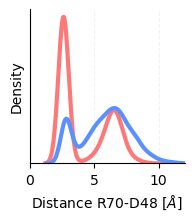

In [19]:
fig, ax = plt.subplots(figsize=(2, 2))


sns.kdeplot(dist_pre_dat_df[0],color='#FF7878', lw=3)
sns.kdeplot(dist_unb_dat_df[0],color='#5A91FF', lw=3)
# sns.kdeplot(CHI1_pre_rot_s1_df['chi1LYS49.xvg'].to_list()+CHI1_pre_rot_s2_df['chi1LYS49.xvg'].to_list()+\
# CHI1_pre_rot_s3_df['chi1LYS49.xvg'].to_list(), color='#FF7878', lw=3)
# sns.kdeplot(CHI1_bnd_rot_s1_df['chi1LYS49.xvg'].to_list()+CHI1_bnd_rot_s2_df['chi1LYS49.xvg'].to_list()+\
# CHI1_bnd_rot_s3_df['chi1LYS49.xvg'].to_list())
# sns.kdeplot(CHI1_unb_rot_s1_df['chi1LYS49.xvg'].to_list()+CHI1_unb_rot_s2_df['chi1LYS49.xvg'].to_list()+\
# CHI1_unb_rot_s3_df['chi1LYS49.xvg'].to_list(),color='#5A91FF', lw=3)

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)


ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_xlim(0,12)
# ax.set_xticks([0,180,360],[0,180,360])
# ax.set_xticklabels([0,180,360], fontdict=font)

ax.set_xlabel('Distance R70-D48 [$\AA$]')

ax.set_yticks([],[])

# plt.savefig('r70_d48_density.png', dpi=450,
#                bbox_inches='tight', transparent=True)

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[]

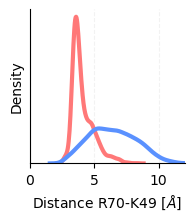

In [21]:
fig, ax = plt.subplots(figsize=(2, 2))


sns.kdeplot(dist_pre_dat_df[1],color='#FF7878', lw=3)
sns.kdeplot(dist_unb_dat_df[1],color='#5A91FF', lw=3)
# sns.kdeplot(CHI1_pre_rot_s1_df['chi1LYS49.xvg'].to_list()+CHI1_pre_rot_s2_df['chi1LYS49.xvg'].to_list()+\
# CHI1_pre_rot_s3_df['chi1LYS49.xvg'].to_list(), color='#FF7878', lw=3)
# sns.kdeplot(CHI1_bnd_rot_s1_df['chi1LYS49.xvg'].to_list()+CHI1_bnd_rot_s2_df['chi1LYS49.xvg'].to_list()+\
# CHI1_bnd_rot_s3_df['chi1LYS49.xvg'].to_list())
# sns.kdeplot(CHI1_unb_rot_s1_df['chi1LYS49.xvg'].to_list()+CHI1_unb_rot_s2_df['chi1LYS49.xvg'].to_list()+\
# CHI1_unb_rot_s3_df['chi1LYS49.xvg'].to_list(),color='#5A91FF', lw=3)

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.1)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.1)


ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_xlim(0,12)
# ax.set_xticks([0,180,360],[0,180,360])
# ax.set_xticklabels([0,180,360], fontdict=font)

ax.set_xlabel('Distance R70-K49 [$\AA$]')

ax.set_yticks([],[])

# plt.savefig('r70_d48_density.png', dpi=450,
#                bbox_inches='tight', transparent=True)